# FRAUD DETECTION 

## Important Librarires

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

In [2]:
fraud_df = pl.read_csv("fraud.csv")

## Exploratory Data Analysis & Understannding The Data

In [3]:
fraud_df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64
1,"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,"""M1979787155""",0.0,0.0,0,0
1,"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,"""M2044282225""",0.0,0.0,0,0
1,"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,"""C553264065""",0.0,0.0,1,0
1,"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,"""C38997010""",21182.0,0.0,1,0
1,"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,"""M1230701703""",0.0,0.0,0,0


In [6]:
fraud_df.null_count()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


**The Dataset contains no Null Values so cleaning is not required**

In [7]:
fraud_df.shape

(6362620, 11)

In [9]:
fraud_df = fraud_df.unique()

In [10]:
fraud_df.shape[0]

6362620

**Data set had no duplicates**

In [11]:
fraud_df["isFraud"].value_counts()

isFraud,count
i64,u32
0,6354407
1,8213


In [12]:
percentage_of_fraud = fraud_df["isFraud"].value_counts()[1]/fraud_df["isFraud"].value_counts().sum()

In [13]:
percentage_of_fraud * 100

isFraud,count
f64,f64
100.0,0.129082


**Only 0.12% of Data is fraud which means it is highly imbalanced**

In [19]:
type_vs_fraud = fraud_df.group_by("type").agg(pl.col("isFraud").mean()).sort("isFraud")

**Grouped Fraud and Types to check the transaction type with most Frauds**

<BarContainer object of 5 artists>

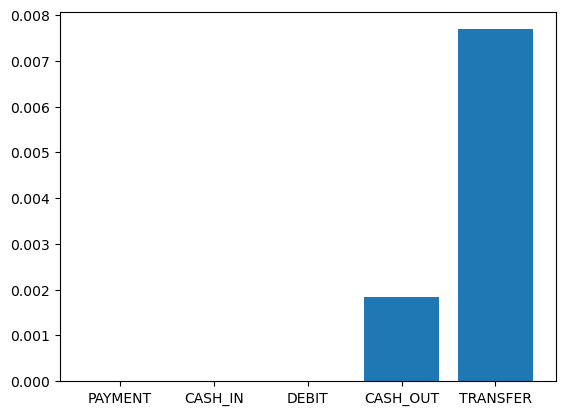

In [25]:
plt.bar(type_vs_fraud["type"], type_vs_fraud["isFraud"])

In [29]:
type_vs_fraud.group_by(pl.all()).len()

type,isFraud,len
str,f64,u32
"""PAYMENT""",0.0,1
"""CASH_IN""",0.0,1
"""TRANSFER""",0.007688,1
"""CASH_OUT""",0.00184,1
"""DEBIT""",0.0,1


**The most frauds are in Transfer type and some in Cash-Out rest transaction types have no frauds**

In [39]:
fraud_df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64
397,"""TRANSFER""",861776.38,"""C1476455285""",9023.51,0.0,"""C2047509221""",2.0782e6,2.9400e6,0,0
189,"""CASH_OUT""",147139.67,"""C72765865""",860.0,0.0,"""C662956647""",3.8632e6,4.0103e6,0,0
332,"""CASH_OUT""",49741.65,"""C2147456523""",40564.0,0.0,"""C691620542""",927722.48,977464.13,0,0
202,"""CASH_OUT""",22473.38,"""C2141051867""",4079.0,0.0,"""C1410788219""",2.4019e6,2.4243e6,0,0
39,"""CASH_IN""",72170.59,"""C696498082""",40196.0,112366.59,"""C851366599""",873871.3,801700.71,0,0


In [40]:
print("Actual Fraud Values",fraud_df["isFraud"].value_counts())
print("Detected Fraud Values",fraud_df["isFlaggedFraud"].value_counts())

Actual Fraud Values shape: (2, 2)
┌─────────┬─────────┐
│ isFraud ┆ count   │
│ ---     ┆ ---     │
│ i64     ┆ u32     │
╞═════════╪═════════╡
│ 0       ┆ 6354407 │
│ 1       ┆ 8213    │
└─────────┴─────────┘
Detected Fraud Values shape: (2, 2)
┌────────────────┬─────────┐
│ isFlaggedFraud ┆ count   │
│ ---            ┆ ---     │
│ i64            ┆ u32     │
╞════════════════╪═════════╡
│ 1              ┆ 16      │
│ 0              ┆ 6362604 │
└────────────────┴─────────┘


**Only 16 values out of the 8213 fraudulent transaction were detected**

## Feature Engineering

In [45]:
fraud_df = fraud_df.with_columns(
    (pl.col("amount") - (pl.col("newbalanceDest") - pl.col("oldbalanceDest"))).round(2).alias("errorBalanceDest"),
    (pl.col("amount") - (pl.col("oldbalanceOrg") - pl.col("newbalanceOrig"))).round(2).alias("errorBalanceOrig"),
)

**We added the features Errors in balance of both the sender and reciever as a correct transaction should have the difference = amount for both sender and reciever**

In [46]:
fraud_df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,errorBalanceDest,errorBalanceOrig
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64,f64,f64,f64
397,"""TRANSFER""",861776.38,"""C1476455285""",9023.51,0.0,"""C2047509221""",2.0782e6,2.9400e6,0,0,9023.51,-0.0,852752.87
189,"""CASH_OUT""",147139.67,"""C72765865""",860.0,0.0,"""C662956647""",3.8632e6,4.0103e6,0,0,860.0,0.0,146279.67
332,"""CASH_OUT""",49741.65,"""C2147456523""",40564.0,0.0,"""C691620542""",927722.48,977464.13,0,0,40564.0,-0.0,9177.65
202,"""CASH_OUT""",22473.38,"""C2141051867""",4079.0,0.0,"""C1410788219""",2.4019e6,2.4243e6,0,0,4079.0,-0.01,18394.38
39,"""CASH_IN""",72170.59,"""C696498082""",40196.0,112366.59,"""C851366599""",873871.3,801700.71,0,0,-72170.59,144341.18,144341.18


In [47]:
fraud_df = fraud_df.with_columns(
    ((pl.col("oldbalanceDest") == 0) & (pl.col("newbalanceDest") == 0) & (pl.col("amount") > 0))
    .cast(pl.Int8)
    .alias("is_dest_zero_after_transaction")
)

**We added this feature to check if the balance of receiver was 0 before and after transaction even though the amount transferred was above 0**

In [48]:
fraud_df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,errorBalanceDest,errorBalanceOrig,is_dest_zero_after_transaction
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64,f64,f64,f64,i8
397,"""TRANSFER""",861776.38,"""C1476455285""",9023.51,0.0,"""C2047509221""",2.0782e6,2.9400e6,0,0,9023.51,-0.0,852752.87,0
189,"""CASH_OUT""",147139.67,"""C72765865""",860.0,0.0,"""C662956647""",3.8632e6,4.0103e6,0,0,860.0,0.0,146279.67,0
332,"""CASH_OUT""",49741.65,"""C2147456523""",40564.0,0.0,"""C691620542""",927722.48,977464.13,0,0,40564.0,-0.0,9177.65,0
202,"""CASH_OUT""",22473.38,"""C2141051867""",4079.0,0.0,"""C1410788219""",2.4019e6,2.4243e6,0,0,4079.0,-0.01,18394.38,0
39,"""CASH_IN""",72170.59,"""C696498082""",40196.0,112366.59,"""C851366599""",873871.3,801700.71,0,0,-72170.59,144341.18,144341.18,0


In [52]:
corr = fraud_df.select([
    pl.corr("errorBalanceDest", "isFraud"),
    pl.corr("errorBalanceOrig", "isFraud"),
    pl.corr("is_dest_zero_after_transaction", "isFraud")
])
print(corr)

shape: (1, 3)
┌──────────────────┬──────────────────┬────────────────────────────────┐
│ errorBalanceDest ┆ errorBalanceOrig ┆ is_dest_zero_after_transaction │
│ ---              ┆ ---              ┆ ---                            │
│ f64              ┆ f64              ┆ f64                            │
╞══════════════════╪══════════════════╪════════════════════════════════╡
│ 0.05512          ┆ -0.011283        ┆ 0.009814                       │
└──────────────────┴──────────────────┴────────────────────────────────┘


**Correlations look insignificant as the data is extremely imbalanced with just a few thousand frauds out of millions of rows. Lets narrow down to the two Types of transactions with most frauds**

In [53]:
fraud_types_df = fraud_df.filter(pl.col("type").is_in(["TRANSFER", "CASH_OUT"]))

corr_filtered = fraud_types_df.select([
    pl.corr("errorBalanceDest", "isFraud"),
    pl.corr("errorBalanceOrig", "isFraud"),
    pl.corr("is_dest_zero_after_transaction", "isFraud")
])
print(corr_filtered)

shape: (1, 3)
┌──────────────────┬──────────────────┬────────────────────────────────┐
│ errorBalanceDest ┆ errorBalanceOrig ┆ is_dest_zero_after_transaction │
│ ---              ┆ ---              ┆ ---                            │
│ f64              ┆ f64              ┆ f64                            │
╞══════════════════╪══════════════════╪════════════════════════════════╡
│ 0.069935         ┆ -0.017149        ┆ 0.589925                       │
└──────────────────┴──────────────────┴────────────────────────────────┘


**Is destination zero after transaction is our best columns as correlation shoots up when narrowed down, fighting the class imbalance**

In [113]:
fraud_df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,errorBalanceDest,errorBalanceOrig,is_dest_zero_after_transaction
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64,f64,f64,f64,i8
397,"""TRANSFER""",861776.38,"""C1476455285""",9023.51,0.0,"""C2047509221""",2.0782e6,2.9400e6,0,0,9023.51,-0.0,852752.87,0
189,"""CASH_OUT""",147139.67,"""C72765865""",860.0,0.0,"""C662956647""",3.8632e6,4.0103e6,0,0,860.0,0.0,146279.67,0
332,"""CASH_OUT""",49741.65,"""C2147456523""",40564.0,0.0,"""C691620542""",927722.48,977464.13,0,0,40564.0,-0.0,9177.65,0
202,"""CASH_OUT""",22473.38,"""C2141051867""",4079.0,0.0,"""C1410788219""",2.4019e6,2.4243e6,0,0,4079.0,-0.01,18394.38,0
39,"""CASH_IN""",72170.59,"""C696498082""",40196.0,112366.59,"""C851366599""",873871.3,801700.71,0,0,-72170.59,144341.18,144341.18,0


## Getting Data Ready for Training and Evaluation

**Lets define the input and output variables with also seperating categorical and numerical columns for pre-processing**

In [76]:
X = fraud_df.drop(["step", "nameOrig", "nameDest", "isFraud", "isFlaggedFraud"])

In [77]:
y = fraud_df["isFraud"]

In [85]:
cat_cols = ["type"]
num_cols =["amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "BalanceDiffOrig", "errorBalanceDest"]

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [87]:
X_test, X_train , y_test , y_train = train_test_split(X , y , test_size = 0.2, random_state = 42)

**Using a column transformer for consistent pre-processing across all models**

In [88]:
transformer = ColumnTransformer(transformers = [
    ("tnf1",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_cols),
    ("tnf2",StandardScaler(),num_cols)
],remainder="drop")

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Making a pipeline to make sure that pre-processing and model are grouped together for future use**

**Examining the Logistic Regression model**

In [90]:
log_reg_pipeline = Pipeline([
    ("preprocessor", transformer),
    ("classifier", LogisticRegression(class_weight="balanced",random_state=42,n_jobs=-1))
])

In [91]:
log_reg_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...), ('tnf2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [92]:
log_reg_preds = log_reg_pipeline.predict(X_test)

In [94]:
accuracy_score(y_test,log_reg_preds )

0.9507936589015217

In [95]:
print(classification_report(y_test, log_reg_preds))
print(confusion_matrix(y_test, log_reg_preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   5083481
           1       0.02      0.95      0.05      6615

    accuracy                           0.95   5090096
   macro avg       0.51      0.95      0.51   5090096
weighted avg       1.00      0.95      0.97   5090096

[[4833316  250165]
 [    300    6315]]


**Although the 95% accuracy might look catchy but looking at Recall which means the model only missed 300 transactions out of 6615 total fraudulent transactions which is good but precision is very bad which means the model labelled almost 250,000 fair transactions as fraud**

In [102]:
from xgboost import XGBClassifier

In [103]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [104]:
xgb_pipeline = Pipeline([
    ("preprocessor", transformer),
    ("classifier", XGBClassifier( n_estimators=300, learning_rate=0.05, 
                                      scale_pos_weight=ratio,  tree_method="hist", n_jobs=-1,
                                      random_state=42,))])

In [105]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...), ('tnf2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
xgb_preds = xgb_pipeline.predict(X_test)

In [107]:
accuracy_score(y_test,xgb_preds)

0.9978670343349123

In [108]:
print(classification_report(y_test, xgb_preds))
print(confusion_matrix(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083481
           1       0.38      0.98      0.54      6615

    accuracy                           1.00   5090096
   macro avg       0.69      0.99      0.77   5090096
weighted avg       1.00      1.00      1.00   5090096

[[5072760   10721]
 [    136    6479]]


**XGBoost has given a very optimum result on this dataset with an accuracy of 99%. The model cannot be considered overfit as even a dumb model would have gotten this accuracy due to extreme imbalance. Giving the model ratio for scale_pos_wight works better as it tells model to prioritise Fraud**

**The most important thing is that recall has improved even more now the model only missed about 136 fraud transactions even better then logistic regression**

**But the most interesting part is that precision has gone up significantly. The logistic regression model flagged almost 250,000 fair transactions as fraud and XGBosst only marked around 10,000 fair as fraud, showing massive improvement**

In [111]:
import joblib

In [112]:
joblib.dump(xgb_pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [117]:
sample_fraud = fraud_df.filter(pl.col("isFraud") == 1).head(10).select(["type","amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest",
                                                                        "newbalanceDest"])
sample_fraud.write_csv("sample_fraud_transactions.csv")

In [119]:
sample_fair = fraud_df.filter(pl.col("isFraud") == 0).head(10).select(["type","amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest",
                                                                       "newbalanceDest"])
sample_fair.write_csv("sample_fair_transactions.csv")